In [1]:
import tensorflow
from tensorflow.keras.models import Model
from keras.layers import *

# Model For Multiple Outputs

In [2]:
x=Input(shape=(3,))

In [3]:
hidden1=Dense(128, activation='relu')(x)
hidden2=Dense(64, activation='relu')(hidden1)

output1=Dense(1, activation='sigmoid')(hidden2)
output2=Dense(1, activation='sigmoid')(hidden2)

In [4]:
model=Model(inputs=x, outputs=[output1, output2])

In [5]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │        512 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         65 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         65 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,898 (34.76 KB)

 Trainable params: 8,898 (34.76 KB)

 Non-trainable params: 0 (0.00 B)

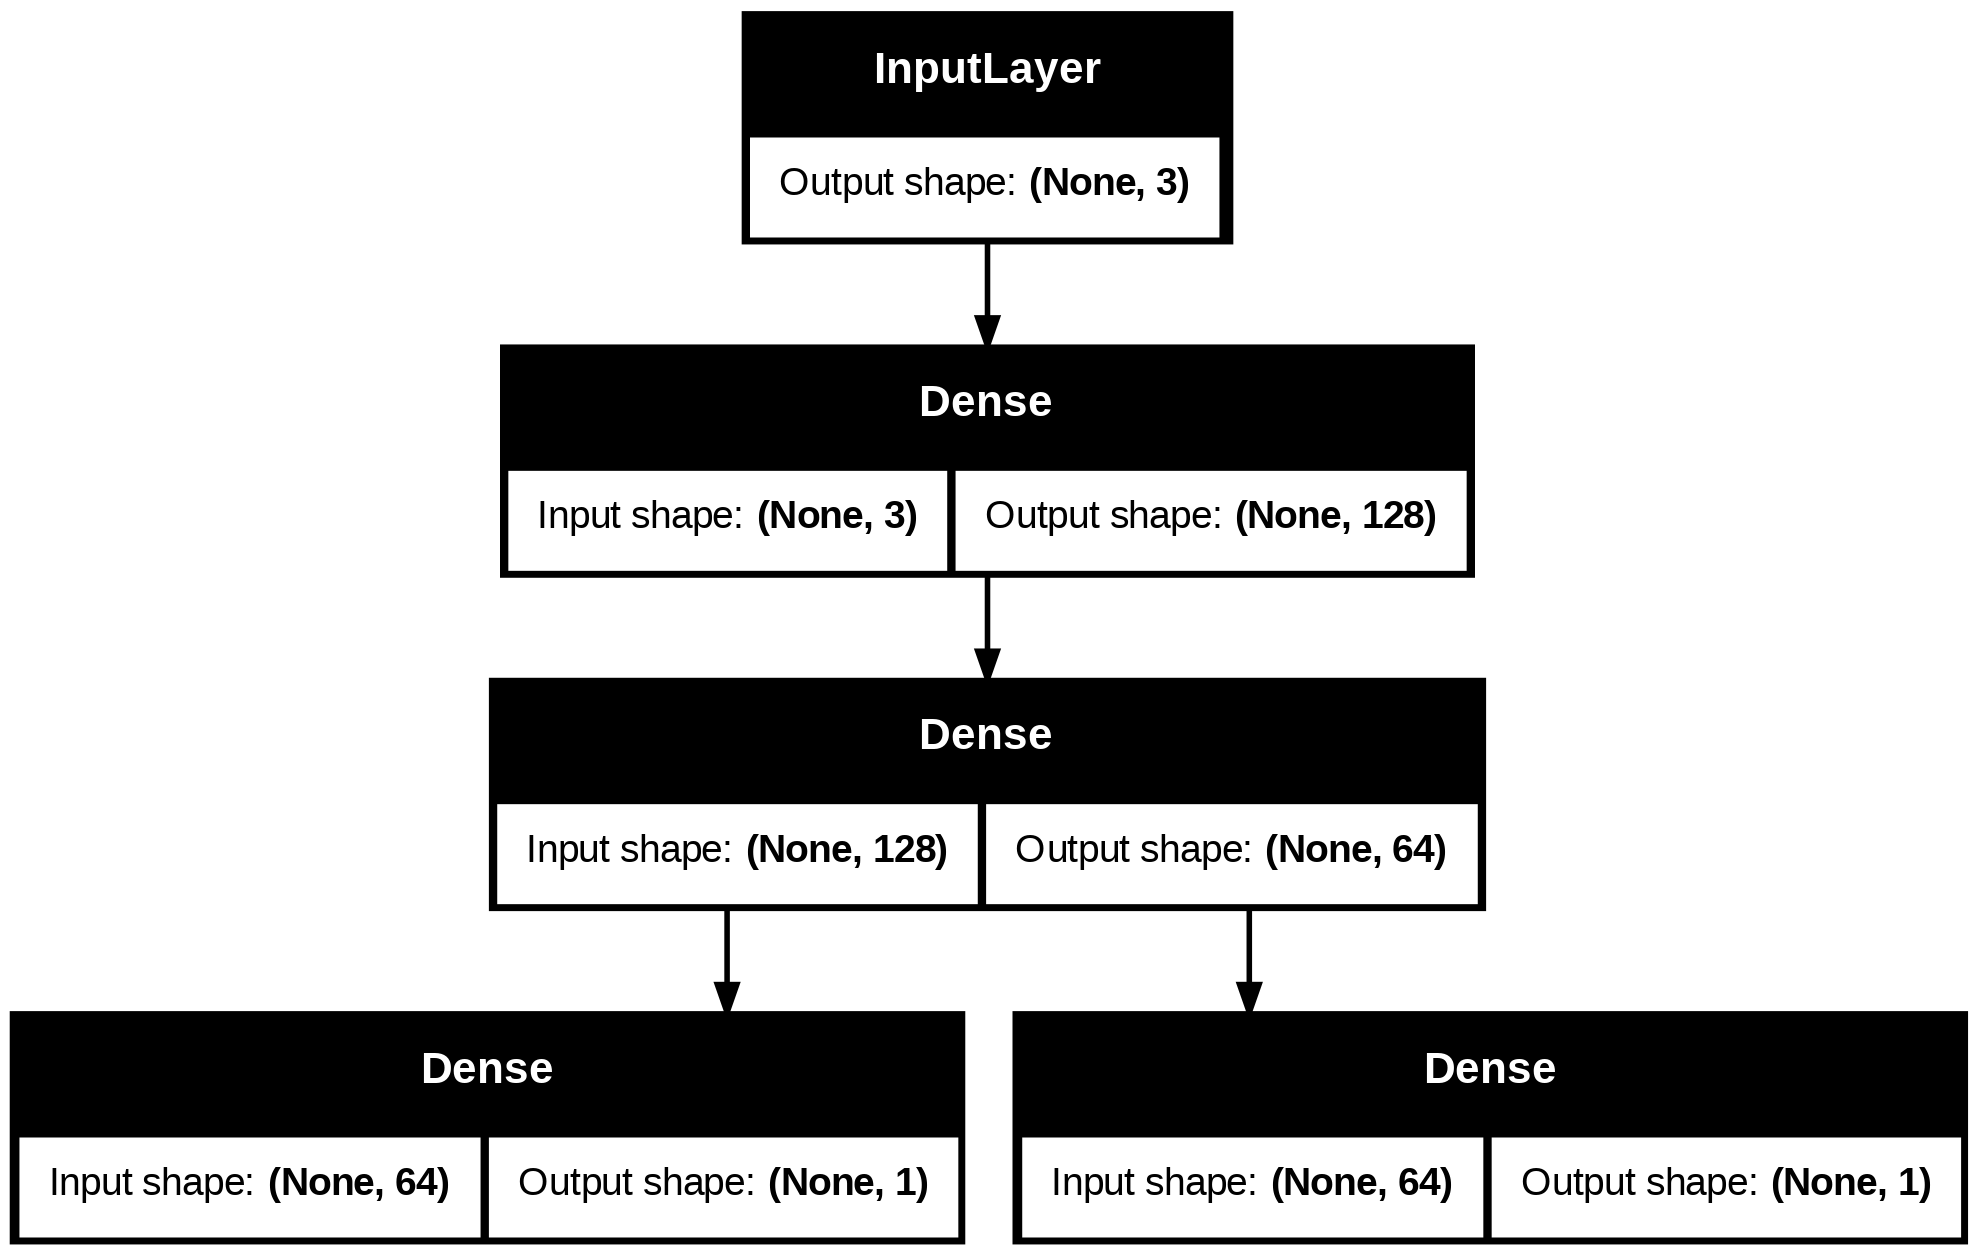

In [6]:
from keras.utils import plot_model
plot_model(model, show_shapes=True)

# Emotion and Age Classification from the Single image taken from kaggle

In [7]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

cp: cannot stat 'kaggle.json': No such file or directory


In [8]:
!kaggle datasets download -d jangedoo/utkface-new

Dataset URL: https://www.kaggle.com/datasets/jangedoo/utkface-new
License(s): copyright-authors
100% 331M/331M [00:16<00:00, 21.1MB/s]



In [9]:
import zipfile
zip = zipfile.ZipFile("/content/utkface-new.zip",'r')
zip.extractall("/content")
zip.close()

In [10]:
import os
import pandas as pd

# Define the directory where the images are extracted
# Corrected path: The images are extracted directly into /content/UTKFace
image_dir = '/content/UTKFace'

# Check if the directory exists
if not os.path.exists(image_dir):
    print(f"Error: Image directory not found at {image_dir}. Please check the extraction path.")
else:
    print(f"Image directory found at: {image_dir}")

    # List all files in the image directory
    image_files = [f for f in os.listdir(image_dir) if f.endswith('.jpg')]

    # Prepare lists to store extracted data
    ages = []
    genders = []
    filenames = []

    # Parse filenames to extract age and gender
    for filename in image_files:
        try:
            # Filenames are in format: [age]_[gender]_[race]_[date&time].jpg
            parts = filename.split('_')
            age = int(parts[0])
            gender = int(parts[1]) # 0 for male, 1 for female

            ages.append(age)
            genders.append(gender)
            filenames.append(filename)
        except (ValueError, IndexError):
            # Skip files that don't match the expected naming convention
            print(f"Skipping invalid filename: {filename}")
            continue

    # Create the DataFrame
    df = pd.DataFrame({
        'age': ages,
        'gender': genders,
        'filename': filenames
    })

    # Display the first 5 rows of the DataFrame
    display(df.head())

    # Display basic info about the DataFrame
    print(df.info())


Image directory found at: /content/UTKFace


,age,gender,filename
0,54,1,54_1_0_20170103183730785.jpg.chip.jpg
1,28,0,28_0_3_20170119194935947.jpg.chip.jpg
2,65,0,65_0_0_20170104184048158.jpg.chip.jpg
3,57,0,57_0_3_20170119211459705.jpg.chip.jpg
4,26,0,26_0_1_20170117200522916.jpg.chip.jpg


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23708 entries, 0 to 23707
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   age       23708 non-null  int64 
 1   gender    23708 non-null  int64 
 2   filename  23708 non-null  object
dtypes: int64(2), object(1)
memory usage: 555.8+ KB
None


In [11]:
df

,age,gender,filename
0,54,1,54_1_0_20170103183730785.jpg.chip.jpg
1,28,0,28_0_3_20170119194935947.jpg.chip.jpg
2,65,0,65_0_0_20170104184048158.jpg.chip.jpg
3,57,0,57_0_3_20170119211459705.jpg.chip.jpg
4,26,0,26_0_1_20170117200522916.jpg.chip.jpg
...,...,...,...
23703,19,0,19_0_0_20170117140603777.jpg.chip.jpg
23704,40,1,40_1_1_20170116231247019.jpg.chip.jpg
23705,30,1,30_1_0_20170117193709509.jpg.chip.jpg
23706,4,0,4_0_2_20161219141105897.jpg.chip.jpg


In [12]:
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import Image # For image operations if needed during debugging

# Define the base directory for images (using the correctly identified image_dir)
# The 'image_dir' variable from cell 67f6798c holds the correct path: '/content/UTKFace'
# Let's re-use that for consistency or explicitly set the correct one.
# image_dir was found to be '/content/UTKFace' in cell 67f6798c

# Create the 'full_path' column in the DataFrame using the correct image_dir
df['full_path'] = df['filename'].apply(lambda x: os.path.join(image_dir, x))

# Verify a few paths
print("Example image paths:")
for i in range(5):
    print(df['full_path'].iloc[i])

# Split the data into training and validation sets
# We'll use stratify for gender to ensure balanced distribution
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['gender'])

print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")

Example image paths:
/content/UTKFace/54_1_0_20170103183730785.jpg.chip.jpg
/content/UTKFace/28_0_3_20170119194935947.jpg.chip.jpg
/content/UTKFace/65_0_0_20170104184048158.jpg.chip.jpg
/content/UTKFace/57_0_3_20170119211459705.jpg.chip.jpg
/content/UTKFace/26_0_1_20170117200522916.jpg.chip.jpg
Training samples: 18966
Validation samples: 4742


In [13]:
IMG_WIDTH, IMG_HEIGHT = 224, 224
BATCH_SIZE = 32

# Data Augmentation and Preprocessing
train_datagen = ImageDataGenerator(
    rescale=1./255, # Normalize pixel values to [0,1]
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255) # Only rescale for validation

# Create data generators using flow_from_dataframe
# For multiple outputs, 'y_col' takes a list of column names for the outputs
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='full_path',
    y_col=['age', 'gender'], # Both age and gender will be outputs
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='multi_output',
    shuffle=True
)

validation_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='full_path',
    y_col=['age', 'gender'],
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='multi_output',
    shuffle=False
)

Found 18966 validated image filenames.
Found 4742 validated image filenames.


In [14]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Load VGG16 without the top (classification) layers
vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_WIDTH, IMG_HEIGHT, 3))

# Freeze the convolutional base layers
for layer in vgg_base.layers:
    layer.trainable = False

# Get the output of the VGG base model
x = vgg_base.output

# Flatten the output to feed into dense layers
x = Flatten()(x)

# Shared Dense layers for feature extraction before branching
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

# Age prediction head
age_output = Dense(128, activation='relu')(x)
age_output = Dropout(0.5)(age_output)
age_output = Dense(1, activation='linear', name='age_output')(age_output) # Linear activation for regression

# Gender prediction head
gender_output = Dense(128, activation='relu')(x)
gender_output = Dropout(0.5)(gender_output)
gender_output = Dense(1, activation='sigmoid', name='gender_output')(gender_output) # Sigmoid activation for binary classification

# Create the functional model with two outputs
model_vgg = Model(inputs=vgg_base.input, outputs=[age_output, gender_output])

# Compile the model
model_vgg.compile(
    optimizer=Adam(learning_rate=0.001),
    loss={
        'age_output': 'mse', # Mean Squared Error for age regression
        'gender_output': 'binary_crossentropy' # Binary Crossentropy for gender classification
    },
    metrics={
        'age_output': ['mae'], # Mean Absolute Error for age
        'gender_output': ['accuracy'] # Accuracy for gender
    }
)

# Display the model summary
model_vgg.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 224, 224,  │      1,792 │ input_layer_1[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 224, 224,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 112, 112,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 112, 112,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 112, 112,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 56, 56,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 56, 56,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 56, 56,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 56, 56,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 28, 28,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 28, 28,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 28, 28,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 28, 28,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 14, 14,    │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv1        │ (None, 14, 14,    │  2,359,808 │ block4_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv2        │ (None, 14, 14,    │  2,359,808 │ block5_conv1[0][

 Total params: 21,203,522 (80.89 MB)

 Trainable params: 6,488,834 (24.75 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [15]:
# Helper function to adapt generator output for multi-output model
def create_multi_output_generator(generator):
    while True:
        x, y = next(generator) # Changed from generator.next() to next(generator)
        # y will be a list: [age_labels, gender_labels]
        # We need to convert it to a dictionary matching model output names
        yield x, {'age_output': y[0], 'gender_output': y[1]}

# Create wrapped generators
wrapped_train_generator = create_multi_output_generator(train_generator)
wrapped_validation_generator = create_multi_output_generator(validation_generator)

# Train the model
history = model_vgg.fit(
    wrapped_train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    validation_data=wrapped_validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE,
    epochs=10
)

Epoch 1/10
592/592 ━━━━━━━━━━━━━━━━━━━━ 344s 546ms/step - age_output_loss: 307.2857 - age_output_mae: 13.5185 - gender_output_accuracy: 0.5336 - gender_output_loss: 1.1857 - loss: 308.4715 - val_age_output_loss: 236.1213 - val_age_output_mae: 11.7146 - val_gender_output_accuracy: 0.6163 - val_gender_output_loss: 0.6820 - val_loss: 236.8033
Epoch 2/10
592/592 ━━━━━━━━━━━━━━━━━━━━ 327s 527ms/step - age_output_loss: 249.1288 - age_output_mae: 12.1391 - gender_output_accuracy: 0.5700 - gender_output_loss: 0.6903 - loss: 249.8060 - val_age_output_loss: 211.0419 - val_age_output_mae: 11.1131 - val_gender_output_accuracy: 0.5405 - val_gender_output_loss: 0.6817 - val_loss: 211.7236
Epoch 3/10
592/592 ━━━━━━━━━━━━━━━━━━━━ 314s 530ms/step - age_output_loss: 240.5040 - age_output_mae: 11.8339 - gender_output_accuracy: 0.5760 - gender_output_loss: 0.6826 - loss: 241.2156 - val_age_output_loss: 266.6125 - val_age_output_mae: 12.7794 - val_gender_output_accuracy: 0.6115 - val_gender_output_loss: 0.

The model training is complete. Now, let's visualize the training and validation loss and accuracy curves.

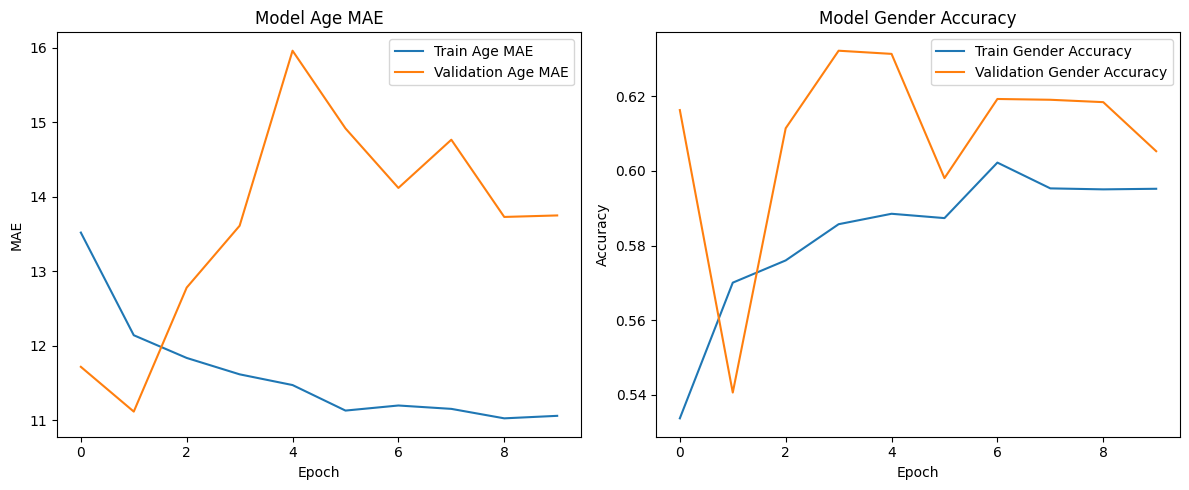

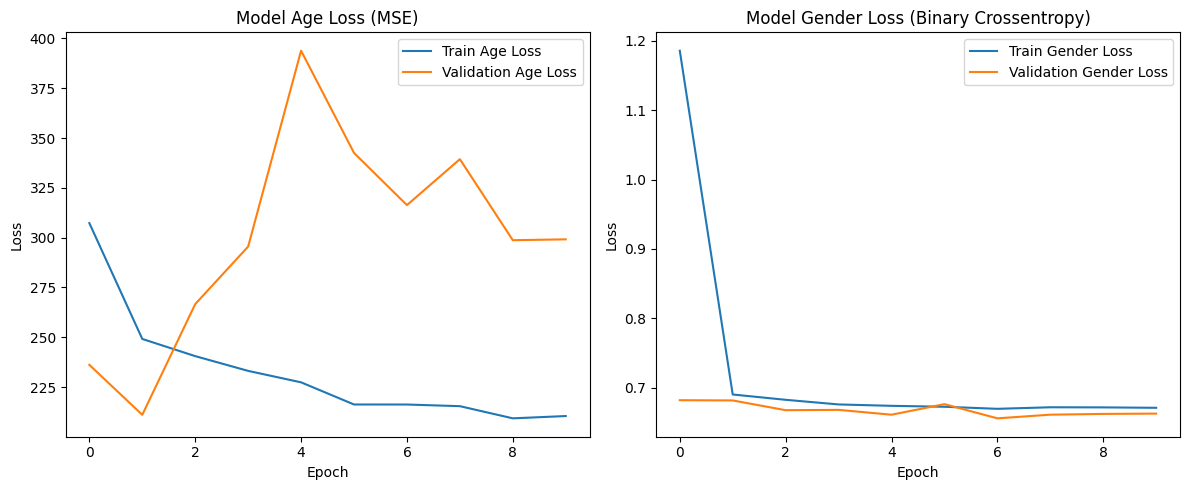

In [16]:
import matplotlib.pyplot as plt

# Plot training history
hist = history.history

plt.figure(figsize=(12, 5))

# Plot Age MAE
plt.subplot(1, 2, 1)
plt.plot(hist['age_output_mae'], label='Train Age MAE')
plt.plot(hist['val_age_output_mae'], label='Validation Age MAE')
plt.title('Model Age MAE')
plt.ylabel('MAE')
plt.xlabel('Epoch')
plt.legend()

# Plot Gender Accuracy
plt.subplot(1, 2, 2)
plt.plot(hist['gender_output_accuracy'], label='Train Gender Accuracy')
plt.plot(hist['val_gender_output_accuracy'], label='Validation Gender Accuracy')
plt.title('Model Gender Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))

# Plot Age Loss
plt.subplot(1, 2, 1)
plt.plot(hist['age_output_loss'], label='Train Age Loss')
plt.plot(hist['val_age_output_loss'], label='Validation Age Loss')
plt.title('Model Age Loss (MSE)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

# Plot Gender Loss
plt.subplot(1, 2, 2)
plt.plot(hist['gender_output_loss'], label='Train Gender Loss')
plt.plot(hist['val_gender_output_loss'], label='Validation Gender Loss')
plt.title('Model Gender Loss (Binary Crossentropy)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

The VGG-based model with two output heads is now defined and compiled. Next, we will train the model for 10 epochs using the data generators.

Now that the data generators are set up, we can proceed to build the VGG-based model with two output heads.